# Spectral Earth Dataset Wrapper Test

In [1]:
import sys
import os

os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)

Adding /home/ando to sys.path


## Test Dataset

In [33]:
from omegaconf import OmegaConf
from geofm_src.factory import create_dataset
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('geofm_src/configs/dataset/tropical_cyclone.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)

INFO:root:[RegDataAugmentation: train] Sampling channels: [0]
INFO:root:[RegDataAugmentation: train] Sampling channels: [0]


torch.Size([1, 224, 224]) tensor([-1.1383])


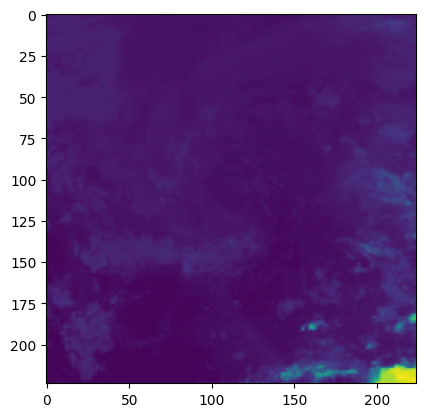

In [42]:
import matplotlib.pyplot as plt
import random

idx = random.randint(0, len(train_ds))

img, label = train_ds[idx]

print(img.shape, label)

if img.shape[0] == 3:
    img = img.permute(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min())
else:
    img = img.squeeze(0)
plt.imshow(img)
plt.show()
